In [8]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings("ignore")

<Axes: ylabel='Frequency'>

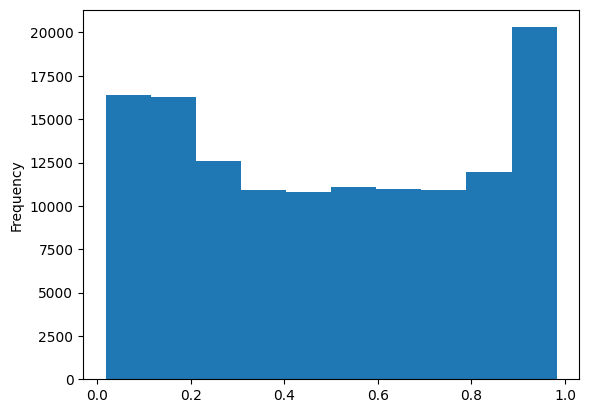

In [9]:


m_team=pd.read_csv('/kaggle/input/competitions/march-machine-learning-mania-2026/MTeams.csv')
w_team=pd.read_csv('/kaggle/input/competitions/march-machine-learning-mania-2026/WTeams.csv')
with open("/kaggle/input/datasets/seddikbenkerrouche/all-submisions/thefans.pkl", "rb") as f: fans = pickle.load(f)
stage2 =pd.read_csv('/kaggle/input/datasets/seddikbenkerrouche/all-submisions/submission.csv')
stage2_2=pd.read_csv('/kaggle/input/datasets/seddikbenkerrouche/all-submisions/sub_E_opt_weights.csv')
stage2_3=pd.read_csv('/kaggle/input/datasets/seddikbenkerrouche/all-submisions/sub_D_seed10.csv')
stage2_4=pd.read_csv('/kaggle/input/datasets/seddikbenkerrouche/all-submisions/sub_D_seed05.csv')
stage2_5=pd.read_csv('/kaggle/input/datasets/seddikbenkerrouche/all-submisions/sub_C_lgb_heavy.csv')
stage2_6=pd.read_csv('/kaggle/input/datasets/seddikbenkerrouche/all-submisions/sub_C_xgb_heavy.csv')
stage2_7=pd.read_csv('/kaggle/input/datasets/seddikbenkerrouche/all-submisions/sub_B_clip_tight.csv')
stage2_8=pd.read_csv('/kaggle/input/datasets/seddikbenkerrouche/all-submisions/sub_B_clip_medium.csv')
stage2_9=pd.read_csv('/kaggle/input/datasets/seddikbenkerrouche/all-submisions/submission_elo.csv')
stage2_10=pd.read_csv('/kaggle/input/datasets/seddikbenkerrouche/all-submisions/submission_stage2_ncaa2026.csv')
stage2['Pred']=(stage2['Pred']+stage2_2['Pred']+stage2_3['Pred']+stage2_4['Pred']+stage2_5['Pred']+stage2_6['Pred']+stage2_7['Pred']+stage2_8['Pred']+stage2_9['Pred']+stage2_10['Pred'])/10

sub=stage2.copy()
sub.to_csv('dd.csv',index=False)
stage2.Pred.plot(kind='hist')


In [10]:
stage2['wins']=stage2['ID'].apply(lambda x:x.split('_')[1])
stage2['losses']=stage2['ID'].apply(lambda x:x.split('_')[2])

stage2['wins']=stage2['wins'].astype(int)
stage2['losses']=stage2['losses'].astype(int)
team=pd.concat([m_team,w_team])
team=team[['TeamID','TeamName']]
team=team.set_index('TeamID')
dicts=team.to_dict()
dicts=dicts['TeamName']
revese_dict={k:v for  v,k in dicts.items()}
stage2['wins']=stage2['wins'].apply(lambda x: dicts[x])
stage2['losses']=stage2['losses'].apply(lambda x: dicts[x])
stage2['sex']=stage2['ID'].apply(lambda x:x.split('_')[1][0])
stage2['sex']=stage2['sex'].astype(int)
stagew=stage2[stage2['sex']==3]
stage2=stage2[stage2['sex']==1]

0.02080758513503922
0.98149511057946


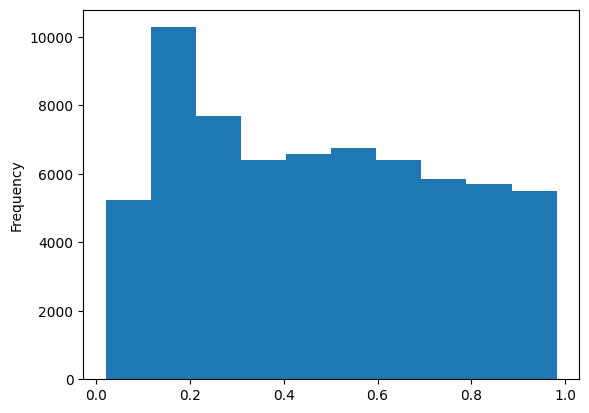

In [11]:

stage2.Pred.plot(kind='hist')
print(stage2.Pred.min())

print(stage2.Pred.max())

In [12]:
#Duke
E=[
    ["Duke","Siena"],
    ["Ohio St","TCU"],
    ["Northern Iowa","St John's"],
    ["Kansas","Cal Baptist"],
    ["Louisville","South Florida"],
    ["Michigan St","N Dakota St"],
    ["UCF","UCLA"],
    ["Connecticut","Furman"]
  ]
 

#Florida
S=[
    ["Florida", "Prairie View" ,"Lehigh"],
    ["Clemson" ,"Iowa"],
    ["McNeese St","Vanderbilt"],
    ["Nebraska" ,"Troy"],
    ["North Carolina", "VCU"],
    ["Illinois" ,"Penn"],
    ["St Mary's CA" ,"Texas A&M"],
    ["Houston", "Idaho"]
    ]


#Arizona
W=[
    ["Arizona","LIU Brooklyn"],
    ["Utah St","Villanova"],
    ["High Point","Wisconsin"],
    ["Arkansas","Hawaii"],
    ["BYU","Texas","NC State"],
    ["Gonzaga","Kennesaw"],
    ["Miami FL","Missouri"],
    ["Purdue","Queens NC"]
]


#Michigan
M=[
    ["Michigan","UMBC","Howard"],
    ["Georgia","St Louis"],
    ["Akron","Texas Tech"],
    ["Alabama","Hofstra"],
    ["Miami OH","Tennessee","SMU"],
    ["Virginia","Wright St"],
    ["Kentucky","Santa Clara"],
    ["Iowa St","Tennessee St"]

    ]



In [13]:
def caluclate_fans(TEAM,ST, expert,weight = [0.01, 0.01, 0.01, 0.01, 0.01, 0.01]):

    

    
    winning_round1 = []
    winning_round2 = []
    winning_round3 = []
    final4=[]
    final=[]
    # -----------------
    # 🥇 ROUND 1
    # -----------------
    for i,( match, direction) in enumerate(zip(TEAM, ST[0])):
    
        teamA, teamB = match[0], match[1]
    
        game = stage2[
            ((stage2["wins"] == teamA) & (stage2["losses"] == teamB)) |
            ((stage2["wins"] == teamB) & (stage2["losses"] == teamA))
        ]
    
        if len(game) == 0:
            continue
    
        idx = game.index[0]
        pred = game["Pred"].values[0]
    
        winner = teamA if direction == 1 else teamB
        loser  = teamB if direction == 1 else teamA
        
       
        # print(f"{teamA:<15} vs {teamB:<15} --> {winner:<15} | proba={pred:.3f}")
        win = game['wins'].values[0]
        pred_team = teamA if direction == 1 else teamB
        stage2.loc[idx, expert] += weight[0] if pred_team == win else -weight[5]  
        
        winning_round1.append(winner)
 
    # -----------------
    # 🥈 ROUND 2
    # -----------------
    round2_matches = [
        (winning_round1[i], winning_round1[i+1])
        for i in range(0, len(winning_round1), 2)
    ]
    
    for (teamA, teamB), direction in zip(round2_matches, ST[1]):
    
        game = stage2[
            ((stage2["wins"] == teamA) & (stage2["losses"] == teamB)) |
            ((stage2["wins"] == teamB) & (stage2["losses"] == teamA))
        ]
    
        if len(game) == 0:
            continue
    
        idx = game.index[0]
        pred = game["Pred"].values[0]
    
        winner = teamA if direction == 1 else teamB
        loser  = teamB if direction == 1 else teamA
        
        model_winner = teamA if pred > 0.5 else teamB
        expert_winner = teamA if direction == 1 else teamB
        
        correct = (expert_winner == model_winner)
        
    
        # print(f"{teamA:<15} vs {teamB:<15} --> {winner:<15} | proba={pred:.3f}")
        win = game['wins'].values[0]
        pred_team = teamA if direction == 1 else teamB
        stage2.loc[idx, expert] += weight[1] if pred_team == win else -weight[4]  
        
        winning_round2.append(winner)

    # -----------------
    # 🥈 ROUND 3
    # -----------------
    round3_matches = [
        (winning_round2[i], winning_round2[i+1])
        for i in range(0, len(winning_round2), 2)
    ]
    
    for (teamA, teamB), direction in zip(round3_matches,  ST[2]):
    
        game = stage2[
            ((stage2["wins"] == teamA) & (stage2["losses"] == teamB)) |
            ((stage2["wins"] == teamB) & (stage2["losses"] == teamA))
        ]
    
        if len(game) == 0:
            continue
    
        idx = game.index[0]
        pred = game["Pred"].values[0]
    
        winner = teamA if direction == 1 else teamB
        loser  = teamB if direction == 1 else teamA
        
        model_winner = teamA if pred > 0.5 else teamB
        expert_winner = teamA if direction == 1 else teamB
        
        correct = (expert_winner == model_winner)
        
    
        # print(f"{teamA:<15} vs {teamB:<15} --> {winner:<15} | proba={pred:.3f}")
        win = game['wins'].values[0]
        pred_team = teamA if direction == 1 else teamB
        stage2.loc[idx, expert] += weight[2] if pred_team == win else -weight[3] 
 
        winning_round3.append(winner)

    round4_matches = [
        (winning_round3[i], winning_round3[i+1])
        for i in range(0, len(winning_round3), 2)
    ]
    
    for (teamA, teamB), direction in zip(round4_matches,  ST[3]):
    
        game = stage2[
            ((stage2["wins"] == teamA) & (stage2["losses"] == teamB)) |
            ((stage2["wins"] == teamB) & (stage2["losses"] == teamA))
        ]
    
        if len(game) == 0:
            continue
    
        idx = game.index[0]
        pred = game["Pred"].values[0]
    
        winner = teamA if direction == 1 else teamB
        loser  = teamB if direction == 1 else teamA
        
        model_winner = teamA if pred > 0.5 else teamB
        expert_winner = teamA if direction == 1 else teamB
        
        correct = (expert_winner == model_winner)
        
        
        # print(f"{teamA:<15} vs {teamB:<15} --> {winner:<15} | proba={pred:.3f}")
        win = game['wins'].values[0]
        pred_team = teamA if direction == 1 else teamB
        stage2.loc[idx, expert] += weight[3] if pred_team == win else -weight[2]   
    
 
            
        final4.append(winner)

    round5_matches = [
        (final4[i], final4[i+1])
        for i in range(0, len(final4), 2)
    ]
    
    for (teamA, teamB), direction in zip(round5_matches,  ST[4]):
    
        game = stage2[
            ((stage2["wins"] == teamA) & (stage2["losses"] == teamB)) |
            ((stage2["wins"] == teamB) & (stage2["losses"] == teamA))
        ]
    
        if len(game) == 0:
            continue
    
        idx = game.index[0]
        pred = game["Pred"].values[0]
    
        winner = teamA if direction == 1 else teamB
        loser  = teamB if direction == 1 else teamA
        # print(f"{teamA:<15} vs {teamB:<15} --> {winner:<15} | proba={pred:.3f}")
        win = game['wins'].values[0]
        pred_team = teamA if direction == 1 else teamB
        stage2.loc[idx, expert] += weight[4] if pred_team == win else -weight[1]  
     
        final.append(winner)
    

    round6_matches = [
        (final[i], final[i+1])
        for i in range(0, len(final), 2)
    ]
    
    for (teamA, teamB), direction in zip(round6_matches,  ST[5]):
    
        game = stage2[
            ((stage2["wins"] == teamA) & (stage2["losses"] == teamB)) |
            ((stage2["wins"] == teamB) & (stage2["losses"] == teamA))
        ]
    
        if len(game) == 0:
            continue
    
        idx = game.index[0]
        pred = game["Pred"].values[0]
   
         
        winner = teamA if direction == 1 else teamB
        loser  = teamB if direction == 1 else teamA
        print(f"{teamA:<15} vs {teamB:<15} --> {winner:<15} | proba={pred:.3f}")
        win = game['wins'].values[0]
        pred_team = teamA if direction == 1 else teamB
        stage2.loc[idx, expert] += weight[5] if pred_team == win else -weight[0]  
    
         
    return stage2 


In [14]:
E=[
    ["Duke","Siena"],
    ["Ohio St","TCU"],
    ["Northern Iowa","St John's"],
    ["Kansas","Cal Baptist"],   
    ["Louisville","South Florida"],
    ["Michigan St","N Dakota St"],
    ["UCF","UCLA"],
    ["Connecticut","Furman"]
  ]

S=[
    ["Florida", "Prairie View" ],
    ["Clemson" ,"Iowa"],
    ["McNeese St","Vanderbilt"],
    ["Nebraska" ,"Troy"],
    ["North Carolina", "VCU"],
    ["Illinois" ,"Penn"],
    ["St Mary's CA" ,"Texas A&M"],
    ["Houston", "Idaho"]
    ]
W=[
    ["Arizona","LIU Brooklyn"],
    ["Utah St","Villanova"],
    ["High Point","Wisconsin"],
    ["Arkansas","Hawaii"],
    ["BYU","Texas"],
    ["Gonzaga","Kennesaw"],
    ["Miami FL","Missouri"],
    ["Purdue","Queens NC"]
]
M=[
    ["Michigan","Howard"],
    ["Georgia","St Louis"],
    ["Akron","Texas Tech"],
    ["Alabama","Hofstra"],
    ["Miami OH","Tennessee"],
    ["Virginia","Wright St"],
    ["Kentucky","Santa Clara"],
    ["Iowa St","Tennessee St"]
    
    ]

TEAM = E + S + W + M
for fa,va in fans.items():
    if fa in ['exp_25']:
        stage2[fa] = 0
        stage2=caluclate_fans(TEAM,va,fa,weight = [0.03]*6)
    else:
        stage2[fa] = 0
        stage2=caluclate_fans(TEAM,va,fa)




fa_cols = [c for c in stage2.columns if "exp_" in c]
stage2["fans_mean"] = stage2[fa_cols].sum(axis=1)

stage2["final"] = 0.9*stage2["Pred"] + 0.25*stage2["fans_mean"] # My bad 0.9/0.1 -----> brier score decrease
stage2["final"] = np.clip(stage2["final"] , 0.005, 0.999)
sub.loc[stage2.index,'Pred']=stage2["final"]

stage3=stagew.copy()

stage3.loc[stage3.ID == '2026_3160_3228', 'Pred'] = 0.32
stage3.loc[stage3.ID == '2026_3268_3293', 'Pred'] = 0.98
stage3.loc[stage3.ID == '2026_3104_3348', 'Pred'] = 0.98
stage3.loc[stage3.ID == '2026_3161_3277', 'Pred'] = 0.11
stage3.loc[stage3.ID == '2026_3355_3449', 'Pred'] = 0.17

stage3.loc[stage3.ID == '2026_3268_3314', 'Pred'] = 0.4
stage3.loc[stage3.ID == '2026_3124_3304', 'Pred'] = 0.65
stage3.loc[stage3.ID == '2026_3163_3376', 'Pred'] = 0.65
stage3.loc[stage3.ID == '2026_3163_3417', 'Pred'] = 0.59

sub.loc[stage3.index,'Pred']=stage3['Pred']
sub.to_csv('submission.csv',index=False)

Houston         vs Arizona         --> Arizona         | proba=0.523
Illinois        vs Arizona         --> Arizona         | proba=0.647
Duke            vs Purdue          --> Purdue          | proba=0.676
Duke            vs Arizona         --> Duke            | proba=0.440
Duke            vs Michigan        --> Michigan        | proba=0.598
Vanderbilt      vs Purdue          --> Purdue          | proba=0.698
Duke            vs Arizona         --> Duke            | proba=0.440
Duke            vs Arizona         --> Arizona         | proba=0.440
Houston         vs Arizona         --> Arizona         | proba=0.523
Florida         vs Iowa St         --> Florida         | proba=0.791
Duke            vs Arizona         --> Duke            | proba=0.440
Duke            vs Arizona         --> Arizona         | proba=0.440
Houston         vs Arizona         --> Arizona         | proba=0.523
Duke            vs Arizona         --> Arizona         | proba=0.440
Illinois        vs Michigan       